## 1. Network Preparation

In [3]:
# Standard library
import os
import re
import sys
import warnings
from pathlib import Path

# Third-party - Data and scientific computing
import contextily as cx
import geopandas as gpd
import igraph as ig
import numpy as np
import pandas as pd
from pyproj import Geod
from tqdm import tqdm

# Shapely-specific imports for spatial analysis
import shapely
from shapely import STRtree
from shapely.geometry import LineString, MultiLineString, Point
from shapely.ops import nearest_points, snap

# Matplotlib-specific imports for figures
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch, Rectangle
from matplotlib.ticker import FuncFormatter, MultipleLocator
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Suppress warnings
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=RuntimeWarning)

In [4]:
BASE_DIR = Path.cwd().parent   # if notebook is in /notebooks

sys.path.append(str(BASE_DIR))
from src.simplify import *

In [5]:
data_path = BASE_DIR / "input_files"
figure_path = BASE_DIR / "figures"
intermediate_path = BASE_DIR / 'intermediate_results'

intermediate_path.mkdir(parents=True, exist_ok=True)

roads_path = data_path / "roads_serbia_original_full_AADT.parquet"
pers_network = gpd.read_parquet(roads_path)

In [6]:
attributes = ['objectid','oznaka_deo','smer_gdf1','kategorija','oznaka_put','oznaka_poc','naziv_poce', 'oznaka_zav', 'naziv_zavr', 'duzina_deo',
       'pocetna_st', 'zavrsna_st','stanje','geometry']                                                

pers_network = pers_network[attributes]

In [7]:
def snap_network_iteratively(gdf, tolerance=2, search_buffer=30):
    """
    Iteratively snap road endpoints to nearby endpoints OR nearby road segments.
    Uses spatial index for efficiency.
    """
    
    def get_endpoints(geom):
        if geom is None or geom.is_empty:
            return None, None
        
        if isinstance(geom, MultiLineString):
            lines = list(geom.geoms)
            if len(lines) == 0:
                return None, None
            first_line = lines[0]
            last_line = lines[-1]
            start_coords = list(first_line.coords)[0]
            end_coords = list(last_line.coords)[-1]
            return Point(start_coords), Point(end_coords)
        
        elif isinstance(geom, LineString):
            coords = list(geom.coords)
            return Point(coords[0]), Point(coords[-1])
        
        else:
            return None, None
    
    gdf = gdf.copy()
    total_snaps = 0
    indices = list(gdf.index)
    
    # Track pairs that have already been snapped
    already_snapped_pairs = set()
    
    iteration = 0
    while True:
        iteration += 1
        snaps_this_round = 0
        snapped_this_round = set()
        
        # Build spatial index fresh each iteration
        geometries = gdf.geometry.tolist()
        tree = STRtree(geometries)
        idx_to_pos = {idx: i for i, idx in enumerate(indices)}
        pos_to_idx = {i: idx for i, idx in enumerate(indices)}
        
        for idx1 in tqdm(indices, desc=f"Iteration {iteration}"):
            if idx1 in snapped_this_round:
                continue
            
            geom1 = gdf.loc[idx1, 'geometry']
            if geom1 is None or geom1.is_empty:
                continue
                
            start1, end1 = get_endpoints(geom1)
            if start1 is None:
                continue
            
            # Find candidate roads within buffer
            buffer_geom = geom1.buffer(search_buffer)
            candidate_positions = tree.query(buffer_geom)
            candidate_indices = [pos_to_idx[pos] for pos in candidate_positions]
            
            for pt1, pos1 in [(start1, 'start'), (end1, 'end')]:
                if idx1 in snapped_this_round:
                    break
                
                for idx2 in candidate_indices:
                    if idx1 == idx2:
                        continue
                    
                    # Skip if this pair was already snapped
                    pair = tuple(sorted([idx1, idx2]))
                    if pair in already_snapped_pairs:
                        continue
                    
                    geom2 = gdf.loc[idx2, 'geometry']
                    if geom2 is None or geom2.is_empty:
                        continue
                    
                    dist = pt1.distance(geom2)
                    
                    if 0 < dist <= tolerance:
                        gdf.loc[idx1, 'geometry'] = snap(
                            gdf.loc[idx1, 'geometry'], 
                            geom2, 
                            tolerance
                        )
                        snapped_this_round.add(idx1)
                        already_snapped_pairs.add(pair)
                        snaps_this_round += 1
                        
                        start1, end1 = get_endpoints(gdf.loc[idx1, 'geometry'])
                        break
        
        print(f"Iteration {iteration} complete: {snaps_this_round} snaps")
        total_snaps += snaps_this_round
        
        if snaps_this_round == 0:
            break
        if iteration > 20:
            print("Max iterations reached")
            break
    
    print(f"\nTotal snaps made: {total_snaps}")
    return gdf

In [8]:
# Run it
pers_network = snap_network_iteratively(pers_network, tolerance=2, search_buffer=30)

Iteration 1: 100%|██████████| 2563/2563 [00:02<00:00, 994.00it/s] 


Iteration 1 complete: 261 snaps


Iteration 2: 100%|██████████| 2563/2563 [00:02<00:00, 1044.59it/s]


Iteration 2 complete: 54 snaps


Iteration 3: 100%|██████████| 2563/2563 [00:02<00:00, 1104.40it/s]


Iteration 3 complete: 6 snaps


Iteration 4: 100%|██████████| 2563/2563 [00:02<00:00, 1090.42it/s]


Iteration 4 complete: 1 snaps


Iteration 5: 100%|██████████| 2563/2563 [00:02<00:00, 1089.36it/s]

Iteration 5 complete: 0 snaps

Total snaps made: 322


In [9]:
# Round coordinates onto a fixed precision grid so that endpoints which now touch
# (post-snapping) become bit-identical rather than differing by floating-point residue —
# this lets node deduplication and topology building correctly merge them into shared nodes.
# Without this, roads that visually touch the network can still be dropped as "disconnected".
SNAP_PRECISION_GRID_SIZE = 0.01  # meters

pers_network['geometry'] = pers_network['geometry'].apply(
    lambda geom: shapely.set_precision(geom, grid_size=SNAP_PRECISION_GRID_SIZE)
)

In [10]:
# Create a Network object from the input DataFrame
net = Network(edges=pers_network)

In [11]:
net = add_endpoints(net)
net = split_edges_at_nodes(net,attributes=['objectid','oznaka_deo','smer_gdf1','kategorija',
                                           'oznaka_put','oznaka_poc','naziv_poce', 'oznaka_zav', 
                                           'naziv_zavr', 'duzina_deo','pocetna_st', 'zavrsna_st','stanje'])
net = add_endpoints(net)
net = add_ids(net)
net = add_topology(net)    

topology: 100%|██████████| 3440/3440 [00:00<00:00, 10379.54it/s]


In [12]:
pers_network = net.edges.set_crs(pers_network.crs)

In [13]:
AADT_path = data_path / "PGDS_2024.shp"
aadt_network = gpd.read_file(AADT_path)

In [14]:
aadt_cols = ['PA', 'BUS', 'LT', 'ST', 'TT', 'AV', 'Ukupno']
aadt_network.dropna(subset=aadt_cols, inplace=True)

In [15]:
aadt_network

,OBJECTID,oznaka_deo,smer,kategorija,oznaka_put,oznaka_poc,naziv_poce,oznaka_zav,naziv_zavr,duzina_deo,...,BUS,LT,ST,TT,AV,Ukupno,Napomena,SHAPE_Le_1,Shape_Le_2,geometry
3,4,A2003,D,IA,A2,A201,petlja Jakovo,A202,petlja Obrenovac,14.153,...,312,473,378,320,2210,25610,АБС 1366/67,0.0,14145.406343,"LINESTRING (7440814.837 4958177.242, 7440814.3..."
4,5,A1002,L,IA,A1,A101,petlja Horgoš,A100,granica MAĐ/SRB (Horgoš),4.245,...,101,88,30,11,954,6260,АБС 2089/90,0.0,4256.939514,"LINESTRING (7418334.847 5112650.115, 7418343.3..."
6,7,A1003,D,IA,A1,A101,petlja Horgoš,A102,petlja Subotica sever,12.603,...,132,114,76,34,1192,7892,ИНТ,0.0,12606.773137,"LINESTRING (7418315.606 5112663.751, 7418314.9..."
9,10,A1004,L,IA,A1,A102,petlja Subotica sever,A101,petlja Horgoš,12.607,...,132,114,76,34,1192,7892,ИНТ,0.0,12599.869429,"LINESTRING (7407247.012 5107612.838, 7407259.8..."
11,12,A1005,D,IA,A1,A102,petlja Subotica sever,A103,petlja Subotica istok,6.296,...,142,165,101,60,1483,9807,ИНТ,0.0,6296.138018,"LINESTRING (7407224.474 5107619.124, 7407215.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1978,1979,02109,O,IB,21,2108,Ruma (veza sa A3 i A8),2109,Jarak,8.378,...,119,184,235,153,1343,10709,ИНТ,0.0,8381.020610,"LINESTRING (7406514.94 4981400.47, 7406518.786..."
1979,1980,10506,O,IIA,105,10504,Bačka Topola (Bečej),A106,petlja Bačka Topola,4.343,...,10,69,50,70,188,3890,ИНТ,0.0,4311.893771,"LINESTRING (7395081.26 5074820.11, 7395078.44 ..."
1980,1981,A8001,D,IA,A8,A305,petlja Ruma,A801,petlja Hrtkovci,12.956,...,94,143,108,78,750,7013,НП,0.0,12956.380355,"LINESTRING (7406240.29 4980567.49, 7406237.77 ..."
1981,1982,A8902,L,IA,A8,A890,Šabac (kraj izgrađenog auto-puta),A801,petlja Hrtkovci,10.451,...,70,106,80,58,557,5209,НП,0.0,10450.807271,"LINESTRING (7396193.009 4963420.889, 7396199.0..."


In [16]:
traffic_types = ['passenger_cars', 'buses', 'light_trucks', 'medium_trucks',
                 'heavy_trucks', 'articulated_vehicles', 'total_aadt']

In [17]:
aadt_cols = ['PA', 'BUS', 'LT', 'ST', 'TT', 'AV', 'Ukupno']
aadt_network.dropna(subset=aadt_cols, inplace=True)

# First merge on oznaka_deo
first_merger = pers_network.merge(
    aadt_network[aadt_cols+['oznaka_deo']], 
    how='left', 
    left_on='oznaka_deo', 
    right_on='oznaka_deo'
)

# Spatial join for unmatched rows
overlap = first_merger.loc[first_merger.PA.isna()][pers_network.columns].sjoin(
    aadt_network[aadt_cols+['oznaka_deo','geometry']], 
    how='left', 
    predicate='intersects'
)

# Get the AADT geometries for the matched index_right values
overlap_with_aadt_geom = overlap.dropna(subset=['index_right']).copy()
overlap_with_aadt_geom['aadt_geometry'] = aadt_network.loc[overlap_with_aadt_geom['index_right'].astype(int), 'geometry'].values

# Calculate intersection and overlap ratio
overlap_with_aadt_geom['intersection_geom'] = overlap_with_aadt_geom.apply(
    lambda row: row['geometry'].intersection(row['aadt_geometry']), axis=1
)
overlap_with_aadt_geom['overlap_ratio'] = (
    overlap_with_aadt_geom['intersection_geom'].length / overlap_with_aadt_geom['geometry'].length
)

# Keep only rows with >= 50% overlap
overlap_filtered = overlap_with_aadt_geom[overlap_with_aadt_geom['overlap_ratio'] >= 0.5].copy()
overlap_filtered = overlap_filtered.drop(columns=['aadt_geometry', 'intersection_geom', 'overlap_ratio'])

first_cols = ['oznaka_deo_left', 'smer_gdf1', 'kategorija', 'oznaka_put', 'oznaka_poc', 
              'naziv_poce', 'oznaka_zav', 'naziv_zavr', 'duzina_deo', 'pocetna_st', 
              'geometry', 'index_right', 'oznaka_deo_right']

agg_dict = {col: 'first' for col in first_cols}
agg_dict.update({col: 'max' for col in aadt_cols})

result = overlap_filtered.dropna(subset=aadt_cols).groupby(level=0).agg(agg_dict)

# Continue with concatenation...
AADT_connected = pd.concat([first_merger.loc[first_merger.dropna(subset=aadt_cols).index], result])
AADT_connected = gpd.GeoDataFrame(pd.concat([AADT_connected,pers_network.loc[~pers_network.index.isin(AADT_connected.index)]]))

AADT_connected = AADT_connected.rename(columns = {
    'PA' : 'passenger_cars', 
    'BUS': 'buses', 
    'LT': 'light_trucks', 
    'ST': 'medium_trucks',  
    'TT': 'heavy_trucks', 
    'AV': 'articulated_vehicles', 
    'Ukupno': 'total_aadt'
}
                     )

AADT_connected[traffic_types] = AADT_connected[traffic_types].astype(np.float64)

# Ensure it's a GeoDataFrame with proper CRS
AADT_connected = gpd.GeoDataFrame(AADT_connected, geometry='geometry')

traffic_cols = ['passenger_cars', 'buses', 'light_trucks', 'medium_trucks', 
                'heavy_trucks', 'articulated_vehicles', 'total_aadt']



c:\Users\yma794\AppData\Local\miniforge3\envs\criticality_env\Lib\site-packages\geopandas\array.py:1754: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as MGI 1901 / Balkans zone 7 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


In [18]:
def get_endpoints(geom):
    """Get start and end points of a linestring or multilinestring"""
    if geom is None or geom.is_empty:
        return None, None
    
    # Handle MultiLineString
    if isinstance(geom, MultiLineString):
        # Get all component linestrings
        lines = list(geom.geoms)
        if len(lines) == 0:
            return None, None
        # Get start of first line and end of last line
        first_line = lines[0]
        last_line = lines[-1]
        start_coords = list(first_line.coords)[0]
        end_coords = list(last_line.coords)[-1]
        return Point(start_coords), Point(end_coords)
    
    # Handle regular LineString
    elif isinstance(geom, LineString):
        coords = list(geom.coords)
        return Point(coords[0]), Point(coords[-1])
    
    else:
        return None, None

def find_touching_roads_with_aadt(idx, gdf, buffer_dist=1):
    """Find roads that touch the endpoints of a given road and have AADT values"""
    row = gdf.loc[idx]
    start_pt, end_pt = get_endpoints(row.geometry)
    
    if start_pt is None:
        return []
    
    touching_roads = []
    for other_idx, other_row in gdf.iterrows():
        if other_idx == idx:
            continue
        if pd.isna(other_row['total_aadt']):
            continue
            
        # Check if endpoints touch the other road
        if other_row.geometry is not None and not other_row.geometry.is_empty:
            if start_pt.buffer(buffer_dist).intersects(other_row.geometry):
                touching_roads.append(('start', other_idx, other_row))
            if end_pt.buffer(buffer_dist).intersects(other_row.geometry):
                touching_roads.append(('end', other_idx, other_row))
    
    return touching_roads

# ============================================
# PASS 1: Fill from both endpoints touching roads with AADT
# ============================================
print("Pass 1: Filling from roads touching both endpoints...")

missing_aadt = AADT_connected[AADT_connected['total_aadt'].isna()].index.tolist()
filled_count_pass1 = 0

for idx in tqdm(missing_aadt,total=len(missing_aadt)):
    touching = find_touching_roads_with_aadt(idx, AADT_connected)
    
    # Check if we have at least one touch at start and one at end
    start_touches = [t for t in touching if t[0] == 'start']
    end_touches = [t for t in touching if t[0] == 'end']
    
    if len(start_touches) > 0 and len(end_touches) > 0:
        # Get AADT values from touching roads
        start_values = {col: np.mean([t[2][col] for t in start_touches]) for col in traffic_cols}
        end_values = {col: np.mean([t[2][col] for t in end_touches]) for col in traffic_cols}
        
        # Take average of start and end
        for col in traffic_cols:
            AADT_connected.loc[idx, col] = (start_values[col] + end_values[col]) / 2
        
        filled_count_pass1 += 1

print(f"Pass 1 filled {filled_count_pass1} roads")

# ============================================
# PASS 2: Fill with median by kategorija, then cap by touching roads
# ============================================
print("Pass 2: Filling with kategorija median...")

# Calculate median values per kategorija
kategoria_medians = AADT_connected.groupby('kategorija')[traffic_cols].median()

missing_aadt = AADT_connected[AADT_connected['total_aadt'].isna()].index.tolist()
filled_count_pass2 = 0

for idx in tqdm(missing_aadt,total=len(missing_aadt)):
    row = AADT_connected.loc[idx]
    kategorija = row['kategorija']
    
    # Skip if no kategorija
    if pd.isna(kategorija) or kategorija not in kategoria_medians.index:
        continue
    
    # Fill with median values
    median_values = kategoria_medians.loc[kategorija]
    for col in traffic_cols:
        AADT_connected.loc[idx, col] = median_values[col]
    
    # Now check touching roads and cap if our value is higher
    touching = find_touching_roads_with_aadt(idx, AADT_connected)
    
    if len(touching) > 0:
        # Get max AADT from any touching road
        max_touching_values = {col: max([t[2][col] for t in touching]) for col in traffic_cols}
        
        # Cap our values if they exceed touching roads
        for col in traffic_cols:
            if AADT_connected.loc[idx, col] > max_touching_values[col]:
                AADT_connected.loc[idx, col] = max_touching_values[col]
    
    filled_count_pass2 += 1

print(f"Pass 2 filled {filled_count_pass2} roads")

# Summary
remaining_missing = AADT_connected['total_aadt'].isna().sum()
print(f"\nRemaining roads without AADT: {remaining_missing}")

Pass 1: Filling from roads touching both endpoints...


100%|██████████| 1959/1959 [08:00<00:00,  4.08it/s]


Pass 1 filled 230 roads
Pass 2: Filling with kategorija median...


100%|██████████| 1729/1729 [05:16<00:00,  5.46it/s] 

Pass 2 filled 986 roads

Remaining roads without AADT: 743


In [19]:
# Load country outline
world_path = data_path / "ne_10m_admin_0_countries.shp"
world = gpd.read_file(world_path)
country = world.loc[world.SOV_A3 == 'KOS']
country = country.to_crs(AADT_connected.crs)

# Dissolve in case there are multiple polygons
kosovo_geom = country.union_all()  # or country.unary_union for older geopandas

# Filter roads that are within Serbia
AADT_Serbia = AADT_connected[~AADT_connected.geometry.intersects(kosovo_geom)].copy()

### PREPARE SEVERAL MAPS TO CHECK THE RESULTS (AND FOR THE REPORT)

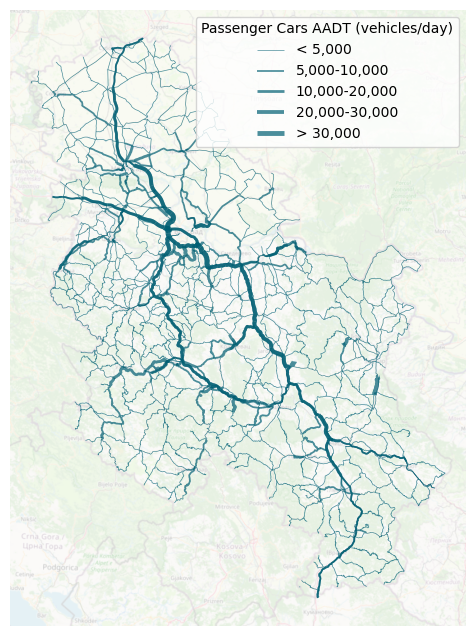

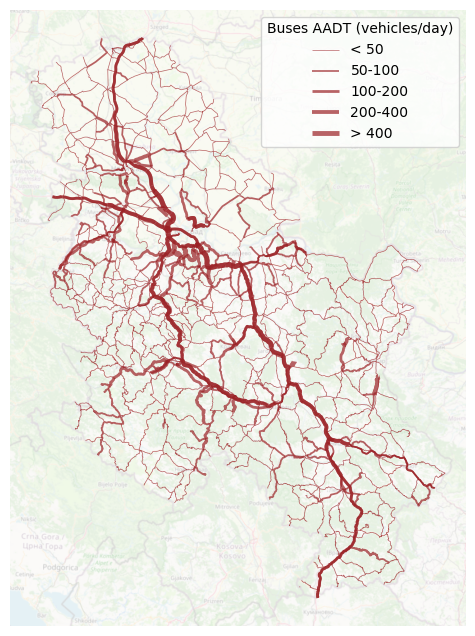

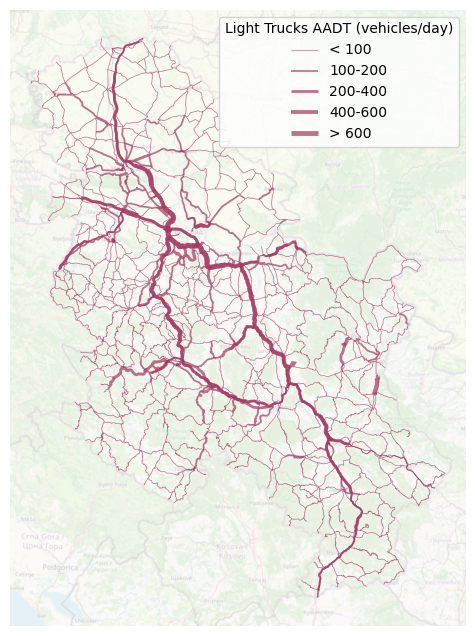

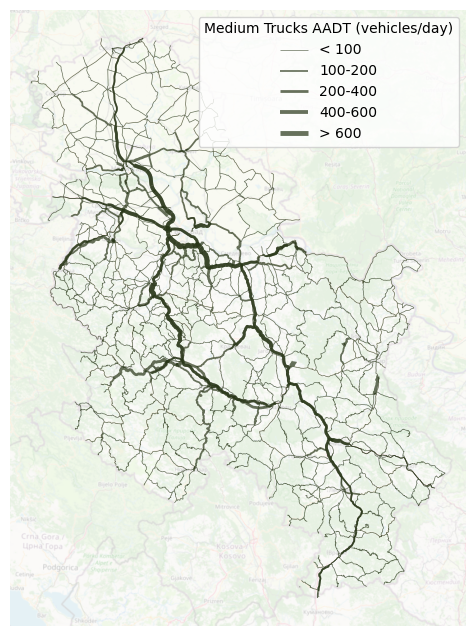

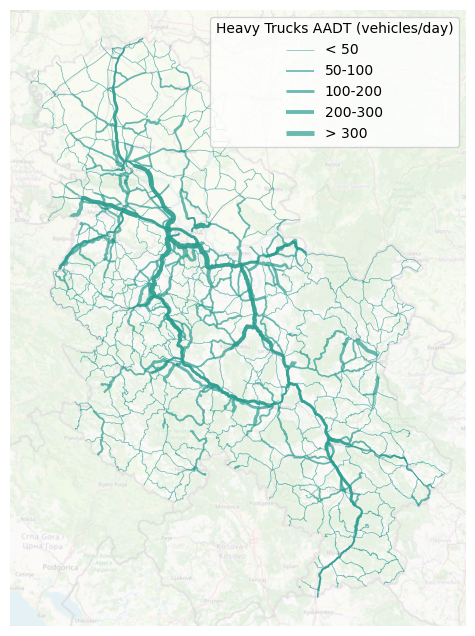

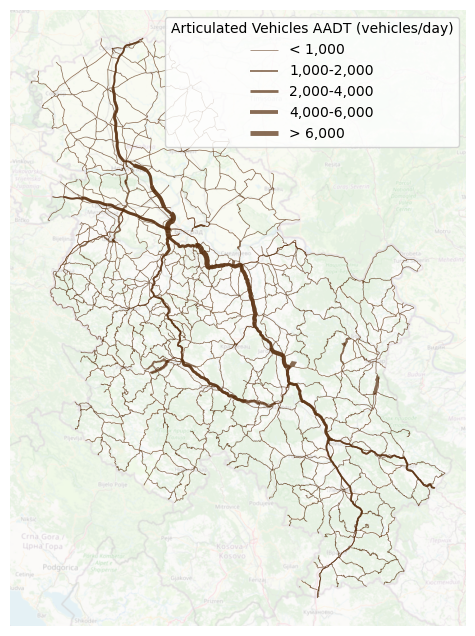

In [20]:
gdf_aadt = AADT_Serbia.copy()

traffic_types = ['passenger_cars', 'buses', 'light_trucks', 'medium_trucks',
                 'heavy_trucks', 'articulated_vehicles', 'total_aadt']

colors = ['#005f73','#9b2226','#a53860','#283618','#2a9d8f','#582f0e','#001219']

legend_titles = {
    'passenger_cars': 'Passenger Cars AADT (vehicles/day)',
    'buses': 'Buses AADT (vehicles/day)', 
    'light_trucks': 'Light Trucks AADT (vehicles/day)',
    'medium_trucks': 'Medium Trucks AADT (vehicles/day)',
    'heavy_trucks': 'Heavy Trucks AADT (vehicles/day)',
    'articulated_vehicles': 'Articulated Vehicles AADT (vehicles/day)',
    'total_aadt': 'Total AADT (vehicles/day)'
}

breaks_labels = {
    'passenger_cars': ([0, 5000, 10000, 20000, 30000, float('inf')], 
                      ['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-30,000', '> 30,000']),
    'buses': ([0, 50, 100, 200, 400, float('inf')], 
              ['< 50', '50-100', '100-200', '200-400', '> 400']),
    'light_trucks': ([0, 100, 200, 400, 600, float('inf')], 
                    ['< 100', '100-200', '200-400', '400-600', '> 600']),
    'medium_trucks': ([0, 100, 200, 400, 600, float('inf')], 
                     ['< 100', '100-200', '200-400', '400-600', '> 600']),
    'heavy_trucks': ([0, 50, 100, 200, 300, float('inf')], 
                    ['< 50', '50-100', '100-200', '200-300', '> 300']),
    'articulated_vehicles': ([0, 1000, 2000, 4000, 6000, float('inf')], 
                           ['< 1,000', '1,000-2,000', '2,000-4,000', '4,000-6,000', '> 6,000']),
    'total_aadt': ([0, 5000, 10000, 20000, 40000, float('inf')], 
                  ['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-40,000', '> 40,000'])
}

width_mappings = {
    'passenger_cars': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-30,000', '> 30,000'])},
    'buses': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 50', '50-100', '100-200', '200-400', '> 400'])},
    'light_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 100', '100-200', '200-400', '400-600', '> 600'])},
    'medium_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 100', '100-200', '200-400', '400-600', '> 600'])},
    'heavy_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 50', '50-100', '100-200', '200-300', '> 300'])},
    'articulated_vehicles': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 1,000', '1,000-2,000', '2,000-4,000', '4,000-6,000', '> 6,000'])},
    'total_aadt': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-40,000', '> 40,000'])}
}

for i, traffic_type in enumerate(traffic_types[:6]):
    breaks, labels = breaks_labels[traffic_type]
    
    # Create categories for this traffic type
    gdf_aadt[f'{traffic_type}_category'] = pd.cut(gdf_aadt[traffic_type], 
                                                  bins=breaks, labels=labels, include_lowest=True)
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    for category in labels:
        subset = gdf_aadt[gdf_aadt[f'{traffic_type}_category'] == category]
        if len(subset) > 0:
            width = width_mappings[traffic_type][category]
            subset.plot(ax=ax, color=colors[i], alpha=0.7,
                       linewidth=width, label=category)
    
    cx.add_basemap(ax=ax, crs=gdf_aadt.crs.to_string(),
                    source=cx.providers.OpenStreetMap.Mapnik, 
                    alpha=0.3, attribution=False)
    ax.legend(title=legend_titles[traffic_type], loc='upper right')
    ax.axis('off')
    plt.savefig(figure_path / f'{traffic_type}_aadt_map.png', dpi=300, bbox_inches='tight')
    plt.show()

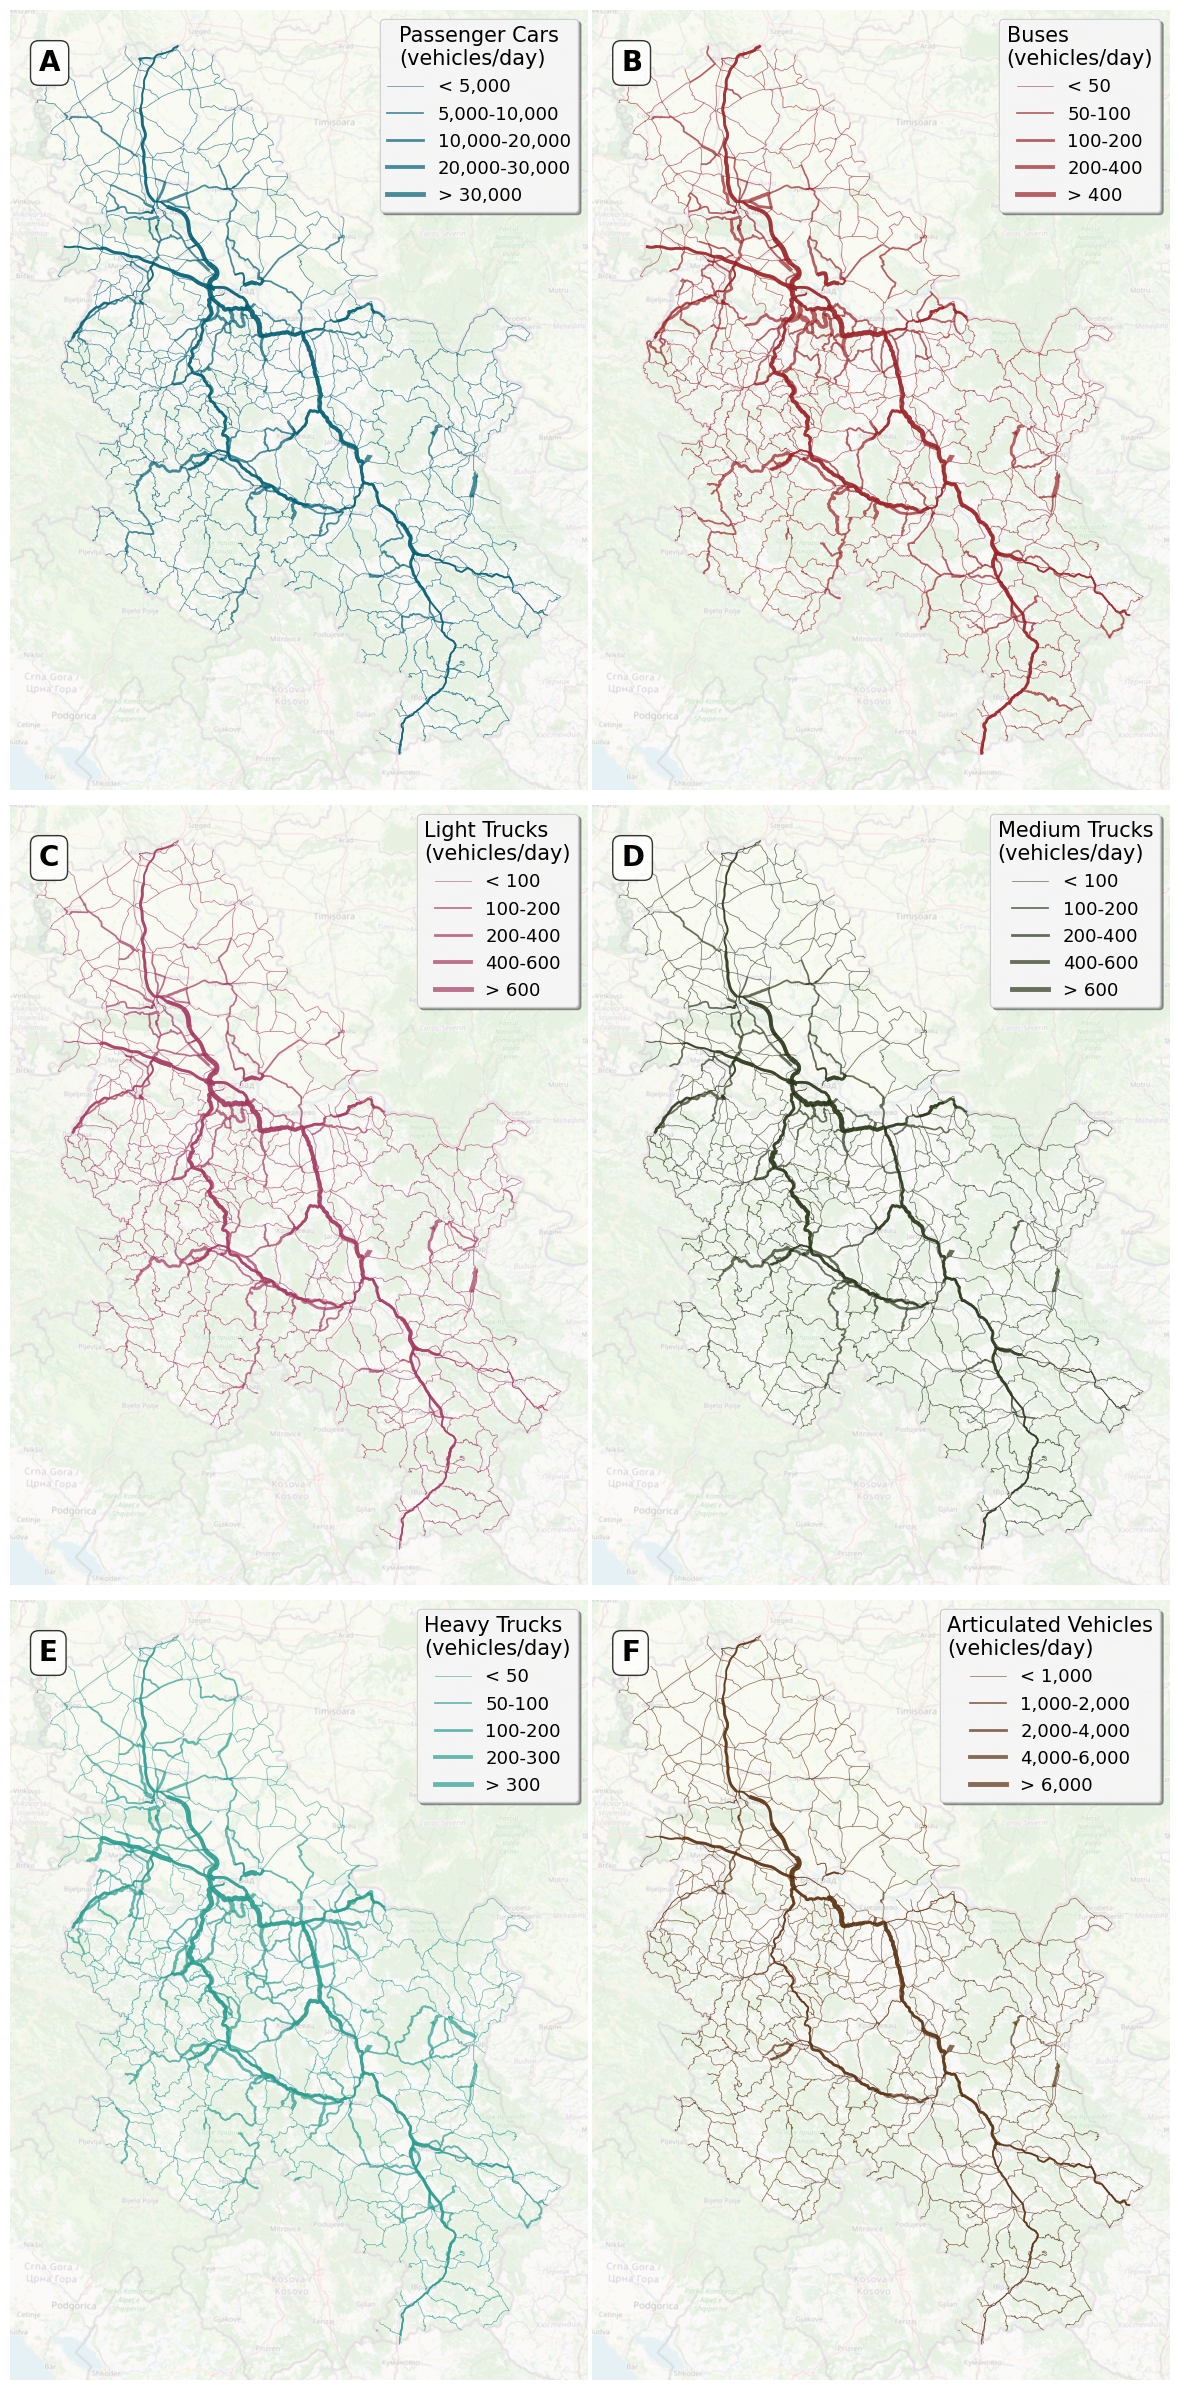

In [21]:
gdf_aadt = AADT_Serbia.copy()

# Exclude 'total_aadt' - only 6 categories
traffic_types = ['passenger_cars', 'buses', 'light_trucks', 'medium_trucks',
                 'heavy_trucks', 'articulated_vehicles']
colors = ['#005f73', '#9b2226', '#a53860', '#283618', '#2a9d8f', '#582f0e']
letters = ['A', 'B', 'C', 'D', 'E', 'F']

legend_titles = {
    'passenger_cars': 'Passenger Cars\n(vehicles/day)',
    'buses': 'Buses\n(vehicles/day)', 
    'light_trucks': 'Light Trucks\n(vehicles/day)',
    'medium_trucks': 'Medium Trucks\n(vehicles/day)',
    'heavy_trucks': 'Heavy Trucks\n(vehicles/day)',
    'articulated_vehicles': 'Articulated Vehicles\n(vehicles/day)'
}

breaks_labels = {
    'passenger_cars': ([0, 5000, 10000, 20000, 30000, float('inf')], 
                      ['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-30,000', '> 30,000']),
    'buses': ([0, 50, 100, 200, 400, float('inf')], 
              ['< 50', '50-100', '100-200', '200-400', '> 400']),
    'light_trucks': ([0, 100, 200, 400, 600, float('inf')], 
                    ['< 100', '100-200', '200-400', '400-600', '> 600']),
    'medium_trucks': ([0, 100, 200, 400, 600, float('inf')], 
                     ['< 100', '100-200', '200-400', '400-600', '> 600']),
    'heavy_trucks': ([0, 50, 100, 200, 300, float('inf')], 
                    ['< 50', '50-100', '100-200', '200-300', '> 300']),
    'articulated_vehicles': ([0, 1000, 2000, 4000, 6000, float('inf')], 
                           ['< 1,000', '1,000-2,000', '2,000-4,000', '4,000-6,000', '> 6,000'])
}

width_mappings = {
    'passenger_cars': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-30,000', '> 30,000'])},
    'buses': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 50', '50-100', '100-200', '200-400', '> 400'])},
    'light_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 100', '100-200', '200-400', '400-600', '> 600'])},
    'medium_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 100', '100-200', '200-400', '400-600', '> 600'])},
    'heavy_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 50', '50-100', '100-200', '200-300', '> 300'])},
    'articulated_vehicles': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 1,000', '1,000-2,000', '2,000-4,000', '4,000-6,000', '> 6,000'])}
}

# Create figure with 3 rows x 2 columns
fig, axes = plt.subplots(3, 2, figsize=(12, 24), facecolor='white')
axes = axes.flatten()  # Flatten to easily iterate

for i, traffic_type in enumerate(traffic_types):
    ax = axes[i]
    breaks, labels = breaks_labels[traffic_type]
    
    # Create categories for this traffic type
    gdf_aadt[f'{traffic_type}_category'] = pd.cut(
        gdf_aadt[traffic_type], 
        bins=breaks, labels=labels, include_lowest=True
    )
    
    # Plot each category
    for category in labels:
        subset = gdf_aadt[gdf_aadt[f'{traffic_type}_category'] == category]
        if len(subset) > 0:
            width = width_mappings[traffic_type][category]
            subset.plot(ax=ax, color=colors[i], alpha=0.7, linewidth=width)
    
    # Add basemap
    cx.add_basemap(ax=ax, crs=gdf_aadt.crs.to_string(),
                   source=cx.providers.OpenStreetMap.Mapnik, 
                   alpha=0.3, attribution=False)
    
    # Create legend with line widths
    legend_elements = [
        Line2D([0], [0], color=colors[i], lw=width_mappings[traffic_type][cat], 
               label=cat, alpha=0.7)
        for cat in labels
    ]
    ax.legend(handles=legend_elements, title=legend_titles[traffic_type], 
              loc='upper right', fontsize=13, title_fontsize=15,
              frameon=True, fancybox=True, shadow=True,
              framealpha=0.9, facecolor='white', edgecolor='#cccccc')
    
    ax.axis('off')
    
    # Add letter label
    ax.text(0.05, 0.95, letters[i], transform=ax.transAxes, fontsize=20, 
            fontweight='bold', verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(data_path /'AADT_categories_combined.png', dpi=300, bbox_inches='tight')
plt.show()

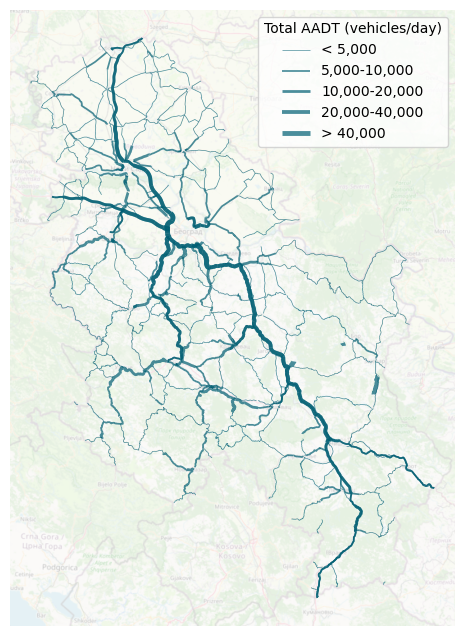

In [22]:
gdf_aadt = aadt_network.copy()
gdf_aadt = gdf_aadt.rename(columns = {
    'PA' : 'passenger_cars', 
    'BUS': 'buses', 
    'LT': 'light_trucks', 
    'ST': 'medium_trucks',  
    'TT': 'heavy_trucks', 
    'AV': 'articulated_vehicles', 
    'Ukupno': 'total_aadt'
}
                     )

gdf_aadt[traffic_types] = gdf_aadt[traffic_types].astype(np.float64)


traffic_types = ['passenger_cars', 'buses', 'light_trucks', 'medium_trucks',
                 'heavy_trucks', 'articulated_vehicles', 'total_aadt']

colors = ['#005f73','#9b2226','#a53860','#283618','#2a9d8f','#582f0e','#001219']

legend_titles = {
    'passenger_cars': 'Passenger Cars AADT (vehicles/day)',
    'buses': 'Buses AADT (vehicles/day)', 
    'light_trucks': 'Light Trucks AADT (vehicles/day)',
    'medium_trucks': 'Medium Trucks AADT (vehicles/day)',
    'heavy_trucks': 'Heavy Trucks AADT (vehicles/day)',
    'articulated_vehicles': 'Articulated Vehicles AADT (vehicles/day)',
    'total_aadt': 'Total AADT (vehicles/day)'
}

breaks_labels = {
    'passenger_cars': ([0, 5000, 10000, 20000, 30000, float('inf')], 
                      ['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-30,000', '> 30,000']),
    'buses': ([0, 50, 100, 200, 400, float('inf')], 
              ['< 50', '50-100', '100-200', '200-400', '> 400']),
    'light_trucks': ([0, 100, 200, 400, 600, float('inf')], 
                    ['< 100', '100-200', '200-400', '400-600', '> 600']),
    'medium_trucks': ([0, 100, 200, 400, 600, float('inf')], 
                     ['< 100', '100-200', '200-400', '400-600', '> 600']),
    'heavy_trucks': ([0, 50, 100, 200, 300, float('inf')], 
                    ['< 50', '50-100', '100-200', '200-300', '> 300']),
    'articulated_vehicles': ([0, 1000, 2000, 4000, 6000, float('inf')], 
                           ['< 1,000', '1,000-2,000', '2,000-4,000', '4,000-6,000', '> 6,000']),
    'total_aadt': ([0, 5000, 10000, 20000, 40000, float('inf')], 
                  ['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-40,000', '> 40,000'])
}

width_mappings = {
    'passenger_cars': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-30,000', '> 30,000'])},
    'buses': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 50', '50-100', '100-200', '200-400', '> 400'])},
    'light_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 100', '100-200', '200-400', '400-600', '> 600'])},
    'medium_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 100', '100-200', '200-400', '400-600', '> 600'])},
    'heavy_trucks': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 50', '50-100', '100-200', '200-300', '> 300'])},
    'articulated_vehicles': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 1,000', '1,000-2,000', '2,000-4,000', '4,000-6,000', '> 6,000'])},
    'total_aadt': {cat: 0.5 + i * 0.75 for i, cat in enumerate(['< 5,000', '5,000-10,000', '10,000-20,000', '20,000-40,000', '> 40,000'])}
}

for i, traffic_type in enumerate(traffic_types[6:]):
    breaks, labels = breaks_labels[traffic_type]
    
    # Create categories for this traffic type
    gdf_aadt[f'{traffic_type}_category'] = pd.cut(gdf_aadt[traffic_type].astype(np.float64), bins=breaks, labels=labels, include_lowest=True)
    
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    for category in labels:
        subset = gdf_aadt[gdf_aadt[f'{traffic_type}_category'] == category]
        if len(subset) > 0:
            width = width_mappings[traffic_type][category]
            subset.plot(ax=ax, color=colors[i], alpha=0.7,
                       linewidth=width, label=category)
    
    cx.add_basemap(ax=ax, crs=gdf_aadt.crs.to_string(),
                    source=cx.providers.OpenStreetMap.Mapnik, 
                    alpha=0.3, attribution=False)
    ax.legend(title=legend_titles[traffic_type], loc='upper right')
    ax.axis('off')
    plt.savefig(figure_path / f'{traffic_type}_aadt_map_og.png', dpi=300, bbox_inches='tight')
    plt.show()

## Prepare creation of fully connected network with correct attributes 

In [35]:
attributes = ['oznaka_deo', 'smer_gdf1', 'kategorija', 'oznaka_put', 'oznaka_poc',
       'naziv_poce', 'oznaka_zav', 'naziv_zavr', 'duzina_deo', 'pocetna_st',
       'zavrsna_st', 'stanje','passenger_cars', 'buses','light_trucks', 'medium_trucks', 'heavy_trucks', 'articulated_vehicles',
       'total_aadt']

In [36]:
# Re-apply precision grid before rebuilding topology — split_edges_at_nodes can introduce
# new vertex coordinates with floating-point residue, so touching endpoints may have
# become non-identical again. Rounding here ensures node deduplication works correctly.
AADT_Serbia['geometry'] = AADT_Serbia['geometry'].apply(
    lambda geom: shapely.set_precision(geom, grid_size=SNAP_PRECISION_GRID_SIZE)
)

net = Network(edges=AADT_Serbia)
net = add_endpoints(net)
net = add_ids(net)
net = add_topology(net)    
base_network = net.edges.set_crs(AADT_Serbia.crs)

# ── Step 1: Merge near-coincident nodes ────────────────────────────────────────
# Handles floating-point residue leaving two nodes at essentially the same position
# with different WKB (and thus different IDs after add_endpoints).
NODE_MERGE_TOLERANCE = 0.1  # meters

_nodes_df = net.nodes.copy().reset_index(drop=True)
_parent = list(range(len(_nodes_df)))

def _find(x):
    while _parent[x] != x:
        _parent[x] = _parent[_parent[x]]
        x = _parent[x]
    return x

_sindex = shapely.STRtree(_nodes_df.geometry.values)
for _i in range(len(_nodes_df)):
    for _j in _sindex.query(_nodes_df.geometry.iloc[_i].buffer(NODE_MERGE_TOLERANCE)):
        if _j != _i:
            _ri, _rj = _find(_i), _find(_j)
            if _ri != _rj:
                _parent[max(_ri, _rj)] = min(_ri, _rj)

_node_ids = _nodes_df['id'].values
_old_to_canon = {int(_node_ids[_i]): int(_node_ids[_find(_i)]) for _i in range(len(_nodes_df))}
_n_merged = len(_nodes_df) - len(set(_old_to_canon.values()))
print(f"Node merge (step 1): {_n_merged} near-coincident nodes collapsed (tolerance={NODE_MERGE_TOLERANCE} m)")

base_network['from_id'] = base_network['from_id'].map(_old_to_canon).astype(int)
base_network['to_id'] = base_network['to_id'].map(_old_to_canon).astype(int)

# ── Step 2: T-junction repair ──────────────────────────────────────────────────
# set_precision(0.01) moved snapped junction points up to 7 mm off the host edge,
# so split_edges_at_nodes silently skipped those T-junction splits. The connector road
# ends up with an isolated node that lies on the host edge geometrically but shares no
# topology node with it. Fix: reassign the isolated node to the nearest endpoint of the
# host edge, force-connecting the road into the topology.
_bn_geoms = list(base_network.geometry)
_bn_sindex = shapely.STRtree(_bn_geoms)
_bn_idx = list(base_network.index)

# Build node-id → position from base_network edge endpoints
_nid_to_pt = {}
for _ei in base_network.index:
    _g = base_network.at[_ei, 'geometry']
    _fid = int(base_network.at[_ei, 'from_id'])
    _tid = int(base_network.at[_ei, 'to_id'])
    if _fid not in _nid_to_pt:
        _nid_to_pt[_fid] = Point(_g.coords[0])
    if _tid not in _nid_to_pt:
        _nid_to_pt[_tid] = Point(_g.coords[-1])

_tjunc_remap = {}
for _nid, _pt in _nid_to_pt.items():
    for _c in _bn_sindex.query(_pt.buffer(1e-2)):  # 1 cm search radius
        _ei = _bn_idx[_c]
        _efid = int(base_network.at[_ei, 'from_id'])
        _etid = int(base_network.at[_ei, 'to_id'])
        if _nid in (_efid, _etid):
            continue  # this is an endpoint edge of this node — skip
        _eg = _bn_geoms[_c]
        if _pt.distance(_eg) > 1e-4:
            continue  # node not on this edge's geometry
        _e_start = Point(_eg.coords[0])
        _e_end = Point(_eg.coords[-1])
        _ds = _pt.distance(_e_start)
        _de = _pt.distance(_e_end)
        if min(_ds, _de) < 0.01:
            continue  # already within 1 cm of an endpoint — node merge handles this
        # T-junction confirmed: reassign to nearest endpoint node of host edge
        _tjunc_remap[_nid] = _efid if _ds <= _de else _etid
        break

# Transitive closure: handle chains of T-junction nodes
for _ in range(5):
    _changed = False
    for _k in list(_tjunc_remap):
        _v = _tjunc_remap[_k]
        if _v in _tjunc_remap:
            _tjunc_remap[_k] = _tjunc_remap[_v]
            _changed = True
    if not _changed:
        break

if _tjunc_remap:
    base_network['from_id'] = base_network['from_id'].map(
        lambda x: _tjunc_remap.get(int(x), int(x))
    ).astype(int)
    base_network['to_id'] = base_network['to_id'].map(
        lambda x: _tjunc_remap.get(int(x), int(x))
    ).astype(int)
    print(f"T-junction repair (step 2): {len(_tjunc_remap)} nodes reassigned to nearest edge endpoint")
else:
    print("T-junction repair (step 2): no T-junction cases found")


topology: 100%|██████████| 3234/3234 [00:00<00:00, 11026.55it/s]


Node merge (step 1): 3 near-coincident nodes collapsed (tolerance=0.1 m)
T-junction repair (step 2): no T-junction cases found


In [37]:
# Step 1: Filter for roads that are not oneway
non_oneway_mask = ~base_network['smer_gdf1'].isin(['L', 'D'])

# Diagnostic: print all smer_gdf1 values present on non-oneway roads
smer_counts = base_network.loc[non_oneway_mask, 'smer_gdf1'].value_counts(dropna=False)
print(f"Non-oneway smer_gdf1 values (total {non_oneway_mask.sum()} roads):")
for val, count in smer_counts.items():
    print(f"  {repr(val)}: {count}")

# Halve AADT on bidirectional roads — original values are sum of both directions
base_network.loc[non_oneway_mask, traffic_types] = base_network.loc[non_oneway_mask, traffic_types] / 2
non_oneway_roads = base_network[non_oneway_mask]

# Step 2: Create reverse edges
def reverse_road(row):
    reversed_geometry = shapely.LineString(row['geometry'].coords[::-1])
    new_row = row.copy()
    new_row['from_id'], new_row['to_id'] = row['to_id'], row['from_id']
    new_row['geometry'] = reversed_geometry
    return new_row

# Step 3: Apply the reverse function to each row
reversed_edges = non_oneway_roads.apply(reverse_road, axis=1)

# Step 4: Append reversed edges back to the original GeoDataFrame
base_network = gpd.GeoDataFrame(pd.concat([base_network, reversed_edges])).reset_index(drop=True)
base_network['id'] = base_network.index

Non-oneway smer_gdf1 values (total 2338 roads):
  'O': 1533
  None: 799
  'M': 6


In [38]:
speed_d = {"IM": 100,
        "IA": 100,
        "IB": 100,
        "IIA": 80,
        "IIB": 80}

def fill_speed(x):
    try:
        return speed_d[x.road_category]
    except Exception:
        return 80

geod = Geod(ellps="WGS84")
base_network['road_length'] = base_network.geometry.apply(lambda line_string: shapely.length(line_string)/1e3) #to_crs(8682).length/1e3
base_network['speed'] = base_network.apply(lambda x: fill_speed(x),axis=1)
base_network['fft'] = base_network.apply(lambda x : ((x.road_length)/x.speed),axis=1) 

In [ ]:
## Load the baseline into igraph:
edges = base_network.reindex(['from_id','to_id'] + [x for x in list(base_network.columns) if x not in ['from_id','to_id']],axis=1)
graph = ig.Graph.TupleList(edges.itertuples(index=False), edge_attrs=list(edges.columns)[2:],directed=True)

# Use weak connectivity — treats the network as undirected for component extraction.
# Strong connectivity is too strict for road networks: oneway roads can form
# "enter-only" clusters that are weakly connected but strongly isolated.
giant = graph.connected_components(mode='weak').giant()
giant_ids = set(giant.es['id'])
dropped_mask = ~edges['id'].isin(giant_ids)
n_dropped = int(dropped_mask.sum())

# Reconnect any remaining topology-error roads: dropped roads whose endpoint
# is within the snap tolerance (2 m) of the kept network are precision/split
# failures, not genuine gaps — force-include them.
RECONNECT_THRESHOLD = 2.0  # meters

if n_dropped > 0:
    _kept_geom = edges.loc[~dropped_mask].geometry.union_all()
    _drop_dist = edges.loc[dropped_mask].geometry.apply(
        lambda g: min(Point(g.coords[0]).distance(_kept_geom),
                      Point(g.coords[-1]).distance(_kept_geom))
    )
    _reconnect_idx = _drop_dist[_drop_dist <= RECONNECT_THRESHOLD].index
    if len(_reconnect_idx) > 0:
        giant_ids |= set(edges.loc[_reconnect_idx, 'id'])
        dropped_mask = ~edges['id'].isin(giant_ids)
        n_dropped = int(dropped_mask.sum())
        print(f"Reconnected {len(_reconnect_idx)} topology-error roads "
              f"(endpoint <= {RECONNECT_THRESHOLD} m from kept network).")

if n_dropped == 0:
    print("Giant component check: no roads dropped, full network is connected.")
else:
    total_length = edges['road_length'].sum()
    giant_length = edges.loc[~dropped_mask, 'road_length'].sum()
    dropped_length = edges.loc[dropped_mask, 'road_length'].sum()
    length_fraction = giant_length / total_length

    print(f"Giant component check: {n_dropped} of {len(edges)} roads "
          f"({100 * n_dropped / len(edges):.2f}%) dropped.")
    print(f"  By number of roads : kept {len(edges) - n_dropped}/{len(edges)} "
          f"({100 * (len(edges) - n_dropped) / len(edges):.2f}%)")
    print(f"  By road length     : kept {giant_length:.2f}/{total_length:.2f} km "
          f"({100 * length_fraction:.2f}%), dropped {dropped_length:.2f} km")

    if length_fraction < 0.95:
        _kept_nodes = set(edges.loc[~dropped_mask, 'from_id']) | set(edges.loc[~dropped_mask, 'to_id'])
        _dropped_nodes = set(edges.loc[dropped_mask, 'from_id']) | set(edges.loc[dropped_mask, 'to_id'])
        print(f"  Topology: {len(_dropped_nodes & _kept_nodes)} of {len(_dropped_nodes)} "
              f"dropped-road node IDs also appear in kept roads")

        dropped_edges = gpd.GeoDataFrame(edges.loc[dropped_mask]).reset_index(drop=True).set_crs(AADT_Serbia.crs)
        dropped_path = intermediate_path / 'PERS_dropped_features.parquet'
        dropped_edges.to_parquet(dropped_path)
        print(f"  Dropped roads saved to {dropped_path.resolve()}")

        kept_union = gpd.GeoDataFrame(edges.loc[~dropped_mask]).union_all()
        dist_to_network = dropped_edges.geometry.apply(
            lambda g: min(Point(g.coords[0]).distance(kept_union),
                          Point(g.coords[-1]).distance(kept_union))
        )
        print("\n  Distance from each dropped road's nearest endpoint to kept network (m):")
        print(dist_to_network.to_string())

        fig, ax = plt.subplots(1, 1, figsize=(16, 8))
        edges.loc[~dropped_mask].plot(ax=ax, color='grey', linewidth=0.5, label='Included')
        edges.loc[dropped_mask].plot(ax=ax, color='red', linewidth=1.5, label='Dropped')
        ax.legend(title='Giant component check', loc='upper right')
        ax.axis('off')
        plt.savefig(figure_path / 'giant_component_dropped_roads.png', dpi=300, bbox_inches='tight')
        plt.show()

        assert length_fraction >= 0.95, (
            f"Giant component represents only {100 * length_fraction:.2f}% of the original "
            f"network length — below the required 95% threshold."
        )

edges = edges[edges['id'].isin(giant_ids)]

### And save the network for further analysis

In [40]:
edges.reset_index(drop=True).set_crs(AADT_Serbia.crs).to_parquet(intermediate_path / 'PERS_directed_final.parquet')